In [ ]:
dataset_url = "https://www.kaggle.com/datasets/gajendramandalcsvtu/custum-dataset-and-public-data-for-model-training"

### 1. Download and Extract the Dataset from Kaggle
Since we are using the dataset URL (`https://www.kaggle.com/datasets/gajendramandalcsvtu/custum-dataset-and-public-data-for-model-training`), we will use the `opendatasets` library to easily download it into Colab.

In [ ]:
!pip install -q legacy-cgi opendatasets

In [ ]:
import os
import json
import opendatasets as od
from google.colab import userdata

# Retrieve Kaggle credentials from Google Colab Secrets
try:
    kaggle_key = userdata.get('KAGGLE_API_KEY')
    try:
        kaggle_username = userdata.get('KAGGLE_USERNAME')
    except Exception:
        kaggle_username = None

    # If credentials exist, write kaggle.json programmatically to bypass interactive prompt
    if kaggle_key:
        if kaggle_key.strip().startswith('{'):
            creds = json.loads(kaggle_key)
        else:
            creds = {
                "username": kaggle_username if kaggle_username else "",
                "key": kaggle_key
            }

        # Write to global ~/.kaggle/ folder
        os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
        with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
            json.dump(creds, f)
        os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

        # Write to local current directory because opendatasets checks here first
        with open('kaggle.json', 'w') as f:
            json.dump(creds, f)

        print("Successfully configured Kaggle credentials globally and locally.")
except Exception as e:
    print(f"Could not load Kaggle credentials from secrets: {e}")

# Download the dataset using the URL
od.download("https://www.kaggle.com/datasets/gajendramandalcsvtu/custum-dataset-and-public-data-for-model-training")

Successfully configured Kaggle credentials from secrets.
Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: 
Your Kaggle username:  
Your Kaggle Key: ··········
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/gajendramandalcsvtu/custum-dataset-and-public-data-for-model-training


100%|██████████| 274M/274M [00:04<00:00, 60.1MB/s]


### 2. Explore, Count, and Plot the Image Categories
We will inspect the directory structure of the downloaded dataset to discover the image categories, count the images in each, and plot these counts.

In [11]:
import os

def print_dir_tree(startpath):
    print(f"Directory Tree structure for: {startpath}\n")
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * level
        subfolder = os.path.basename(root)
        image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
        non_image_files = len(files) - len(image_files)

        if subfolder:
            print(f"{indent}📁 {subfolder}/ (images: {len(image_files)}, other files: {non_image_files})")
        else:
            print(f"📁 [Root] (images: {len(image_files)}, other files: {non_image_files})")

print_dir_tree(dataset_dir)

Directory Tree structure for: ./custum-dataset-and-public-data-for-model-training

📁 custum-dataset-and-public-data-for-model-training/ (images: 0, other files: 3)
    📁 test/ (images: 0, other files: 0)
        📁 labels/ (images: 0, other files: 977)
        📁 images/ (images: 977, other files: 0)
    📁 valid/ (images: 0, other files: 0)
        📁 labels/ (images: 0, other files: 2182)
        📁 images/ (images: 2182, other files: 0)
    📁 train/ (images: 0, other files: 0)
        📁 labels/ (images: 0, other files: 4800)
        📁 images/ (images: 4800, other files: 0)


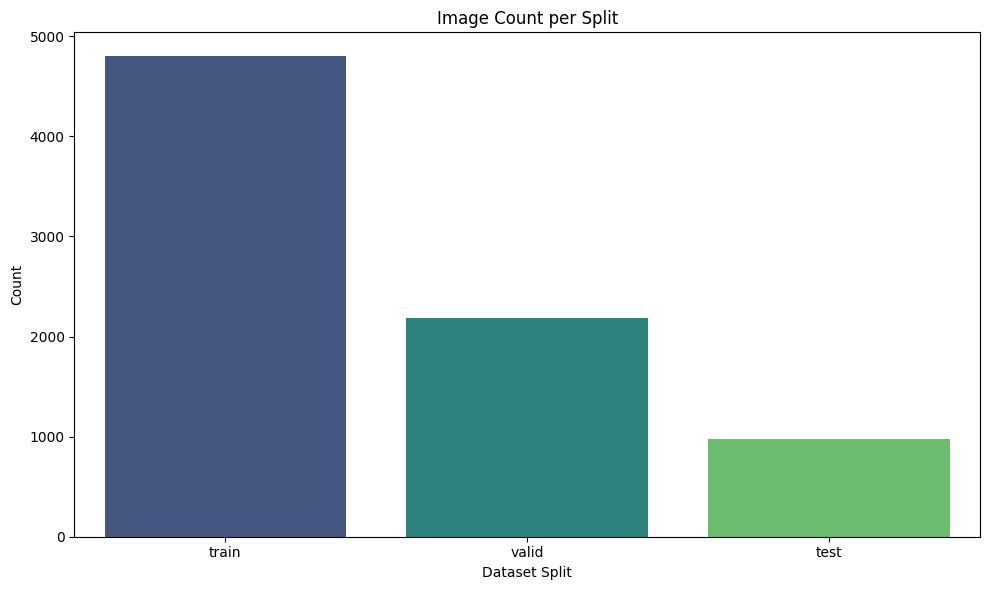

In [12]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

dataset_dir = './custum-dataset-and-public-data-for-model-training'

# Map out the correct image directories
categories = ['train', 'valid', 'test']
file_counts = []
category_paths = {}

for cat in categories:
    # The actual images are located in <category>/images/
    img_dir_path = os.path.join(dataset_dir, cat, 'images')
    category_paths[cat] = img_dir_path
    if os.path.exists(img_dir_path):
        files = [f for f in os.listdir(img_dir_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
        file_counts.append(len(files))
    else:
        file_counts.append(0)

# Plotting the category distributions
plt.figure(figsize=(10, 6))
sns.barplot(x=categories, y=file_counts, hue=categories, palette='viridis', legend=False)
plt.title('Image Count per Split')
plt.xlabel('Dataset Split')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 3. Display Example Images
Let's display some sample images from each detected folder/category to inspect them.

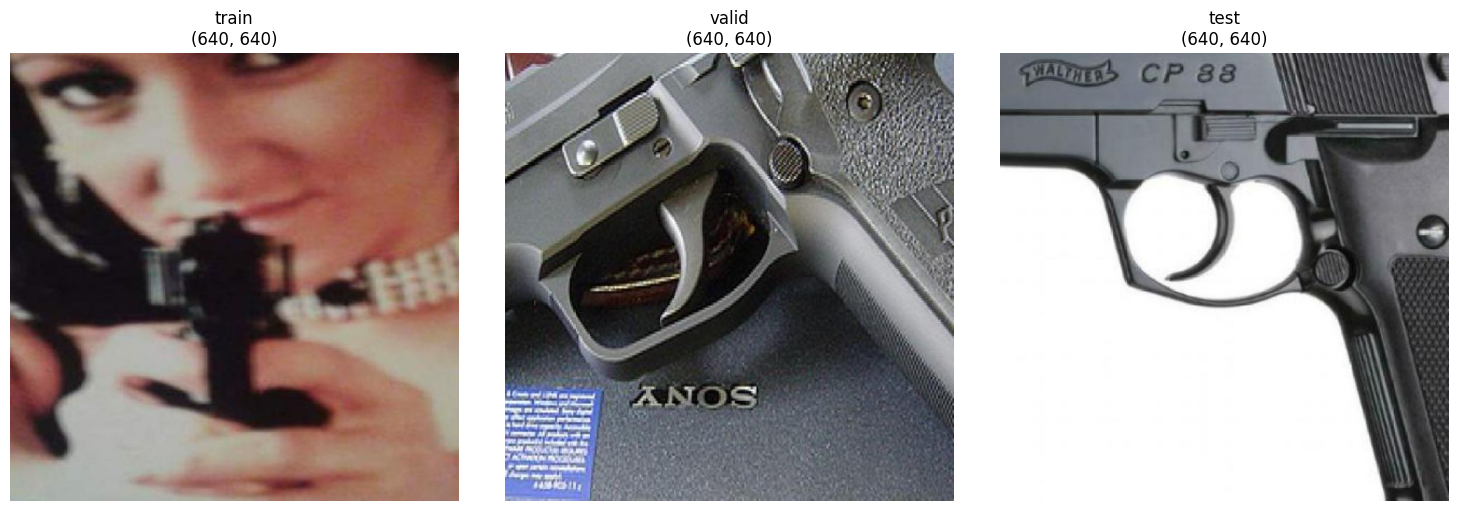

In [13]:
from PIL import Image

fig, axes = plt.subplots(1, len(categories), figsize=(15, 5))
if len(categories) == 1:
    axes = [axes]

for i, category in enumerate(categories):
    cat_path = category_paths[category]
    if os.path.exists(cat_path):
        images = [f for f in os.listdir(cat_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
    else:
        images = []

    if images:
        img_path = os.path.join(cat_path, images[0])
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"{category}\n{img.size}")
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, 'No Image Found', ha='center', va='center')
        axes[i].set_title(category)
        axes[i].axis('off')

plt.tight_layout()
plt.show()

Detected Classes in data.yaml: ['blunt_object', 'gun', 'knife']


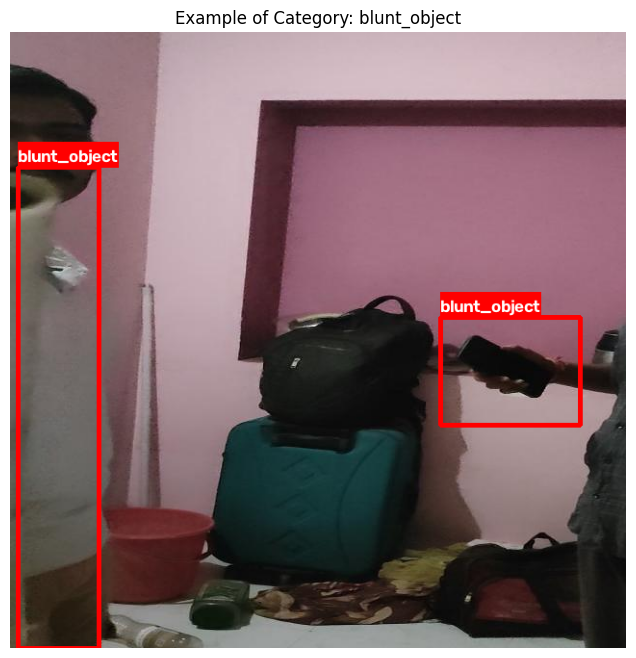

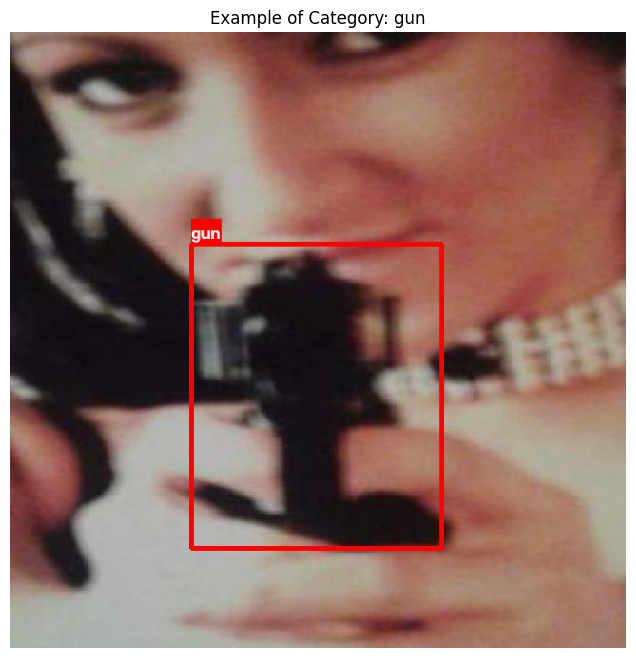

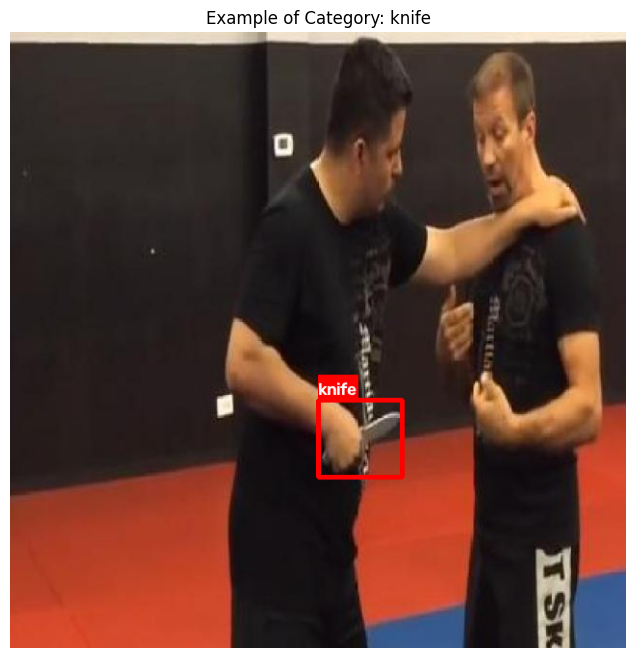

In [14]:
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load category names from data.yaml
yaml_path = os.path.join(dataset_dir, 'data.yaml')
with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

class_names = data_config.get('names', [])
print("Detected Classes in data.yaml:", class_names)

# Helper function to parse YOLO annotations and draw bounding boxes
def draw_annotations(img_path, label_path, class_names):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    if not os.path.exists(label_path):
        return img, []

    detected_classes = []
    with open(label_path, 'r') as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) == 5:
            cls_id = int(parts[0])
            x_center, y_center, bbox_w, bbox_h = map(float, parts[1:])

            # Convert normalized YOLO coordinates to pixel coordinates
            x1 = int((x_center - bbox_w / 2) * w)
            y1 = int((y_center - bbox_h / 2) * h)
            x2 = int((x_center + bbox_w / 2) * w)
            y2 = int((y_center + bbox_h / 2) * h)

            # Draw rectangle
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
            cls_name = class_names[cls_id] if cls_id < len(class_names) else f"Class {cls_id}"
            detected_classes.append(cls_name)

            # Draw label background and text
            label = f"{cls_name}"
            (text_w, text_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(img, (x1, y1 - text_h - 10), (x1 + text_w, y1), (255, 0, 0), -1)
            cv2.putText(img, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    return img, list(set(detected_classes))

# 2. Find examples containing each class
examples_to_plot = {cls_name: None for cls_name in class_names}
train_img_dir = os.path.join(dataset_dir, 'train', 'images')
train_lbl_dir = os.path.join(dataset_dir, 'train', 'labels')

for img_file in os.listdir(train_img_dir):
    if not img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
        continue

    base_name = os.path.splitext(img_file)[0]
    label_file = f"{base_name}.txt"
    img_path = os.path.join(train_img_dir, img_file)
    label_path = os.path.join(train_lbl_dir, label_file)

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) > 0:
                    cls_id = int(parts[0])
                    if cls_id < len(class_names):
                        cls_name = class_names[cls_id]
                        if examples_to_plot[cls_name] is None:
                            examples_to_plot[cls_name] = (img_path, label_path)

    # Break early if we found examples for all categories
    if all(v is not None for v in examples_to_plot.values()):
        break

# 3. Plot the examples
for cls_name, paths in examples_to_plot.items():
    if paths is not None:
        img_path, label_path = paths
        annotated_img, _ = draw_annotations(img_path, label_path, class_names)

        plt.figure(figsize=(8, 8))
        plt.imshow(annotated_img)
        plt.title(f"Example of Category: {cls_name}")
        plt.axis('off')
        plt.show()
    else:
        print(f"Could not find an annotated example for class: {cls_name}")

### 4. Image Preprocessing Steps
We will define a basic image preprocessing pipeline using TensorFlow/Keras to resize, normalize, and augment the images.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

# Configure a basic preprocessing & loading pipeline
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Load the images into a tf.data.Dataset which handles basic resizing
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Preprocessing pipeline: Rescaling pixels to [0, 1] and adding simple augmentations
preprocessing_model = tf.keras.Sequential([
  layers.Rescaling(1./255),
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
])

# Apply preprocessing pipeline to a batch to verify it works
for images, labels in train_ds.take(1):
    preprocessed_images = preprocessing_model(images)
    print("Original batch shape:", images.shape)
    print("Preprocessed batch shape:", preprocessed_images.shape)
    print("Pixel range after rescaling:", tf.reduce_min(preprocessed_images).numpy(), "to", tf.reduce_max(preprocessed_images).numpy())
    break